In [226]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

N = 100
m = 4

# Initialize Library
Network = {node: [] for node in range(N)}



Connect Nodes in Nucleus

In [227]:


# Initial nucleus size
n0 = m + 1

# Connect every node in the nucleus to each other
for node1 in range(n0):
        for node2 in range(node1 + 1 , n0):  # More efficient than adding (if node1 != node2) loop
            Network[node1].append(node2)
            Network[node2].append(node1)

# Debug 
print(Network)

{0: [1, 2, 3, 4], 1: [0, 2, 3, 4], 2: [0, 1, 3, 4], 3: [0, 1, 2, 4], 4: [0, 1, 2, 3], 5: [], 6: [], 7: [], 8: [], 9: [], 10: [], 11: [], 12: [], 13: [], 14: [], 15: [], 16: [], 17: [], 18: [], 19: [], 20: [], 21: [], 22: [], 23: [], 24: [], 25: [], 26: [], 27: [], 28: [], 29: [], 30: [], 31: [], 32: [], 33: [], 34: [], 35: [], 36: [], 37: [], 38: [], 39: [], 40: [], 41: [], 42: [], 43: [], 44: [], 45: [], 46: [], 47: [], 48: [], 49: [], 50: [], 51: [], 52: [], 53: [], 54: [], 55: [], 56: [], 57: [], 58: [], 59: [], 60: [], 61: [], 62: [], 63: [], 64: [], 65: [], 66: [], 67: [], 68: [], 69: [], 70: [], 71: [], 72: [], 73: [], 74: [], 75: [], 76: [], 77: [], 78: [], 79: [], 80: [], 81: [], 82: [], 83: [], 84: [], 85: [], 86: [], 87: [], 88: [], 89: [], 90: [], 91: [], 92: [], 93: [], 94: [], 95: [], 96: [], 97: [], 98: [], 99: []}


Auxilary List

In [228]:
# Initialize Aux. list
aux_list = []

# Initialize initial nucleus nodes
for node in range(n0):
    for i in range(len(Network[node])):
        aux_list.append(node)

print(aux_list)

[0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4]


Create New Nodes

In [229]:
# Add new nodes from n0 to N (where j is the new node)
for j in range(n0, N):

    connected_nodes = []
    while len(connected_nodes) < m:
        # Randomly select attachment node
        the_chosen_node = np.random.choice(aux_list)
        if the_chosen_node not in connected_nodes:
            connected_nodes.append(the_chosen_node)

            # Append 'the_chosen_node' at the index 'new_node' in Network
            # Connect the two using the same method as the initial nucleus
            Network[j].append(the_chosen_node)
            Network[the_chosen_node].append(j)


    # Add number i to each connection made
    for i in connected_nodes:
        aux_list.append(i)

    # Add the new node, j * m for each new vertex i
    aux_list.extend([j] * m)  
    

print(Network)




{0: [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 16, 17, 23, 24, 31, 39, 50, 52, 54, 63, 80, 88, 90, 92], 1: [0, 2, 3, 4, 7, 8, 10, 15, 17, 18, 29, 36, 42, 65, 68, 78, 97], 2: [0, 1, 3, 4, 5, 6, 7, 8, 10, 11, 14, 15, 17, 18, 19, 20, 22, 27, 30, 32, 36, 38, 39, 44, 48, 49, 53, 56, 57, 59, 72, 73, 85, 97, 99], 3: [0, 1, 2, 4, 5, 7, 9, 12, 14, 15, 18, 19, 21, 24, 30, 38, 41, 58, 69, 72, 83, 91], 4: [0, 1, 2, 3, 5, 6, 8, 9, 11, 16, 23, 26, 64, 74], 5: [0, 3, 2, 4, 6, 12, 16, 17, 21, 25, 26, 29, 37, 43, 45, 51, 56, 58, 84, 96], 6: [0, 5, 4, 2, 7, 9, 11, 13, 19, 22, 23, 28, 35, 38, 39, 40, 41, 43, 44, 60, 65, 67, 71, 81, 82, 86, 92, 95], 7: [2, 1, 3, 6, 10, 30, 35, 71, 83, 86, 87, 90, 95], 8: [0, 1, 2, 4, 28, 34, 87], 9: [4, 6, 0, 3, 13, 19, 20, 21, 26, 29, 31, 36, 49, 55, 66, 73, 91], 10: [0, 1, 2, 7, 12, 13, 16, 20, 30, 31, 36, 43, 45, 55, 56, 68, 74, 94], 11: [6, 0, 2, 4, 14, 22, 25, 60, 63, 67, 72, 73, 91, 99], 12: [0, 5, 3, 10, 18, 40, 93], 13: [6, 10, 9, 0, 14, 25, 34, 47, 52, 60, 64, 80, 

In [230]:

k_list = []
mf_approx_list = []
for node in Network:
    k = len(Network[node])
    k_list.append(k)

    # Mean Field Approx
    mf_approx = (2*(m^2)) / (k^3)
    mf_approx_list.append(mf_approx)



Plot Figure

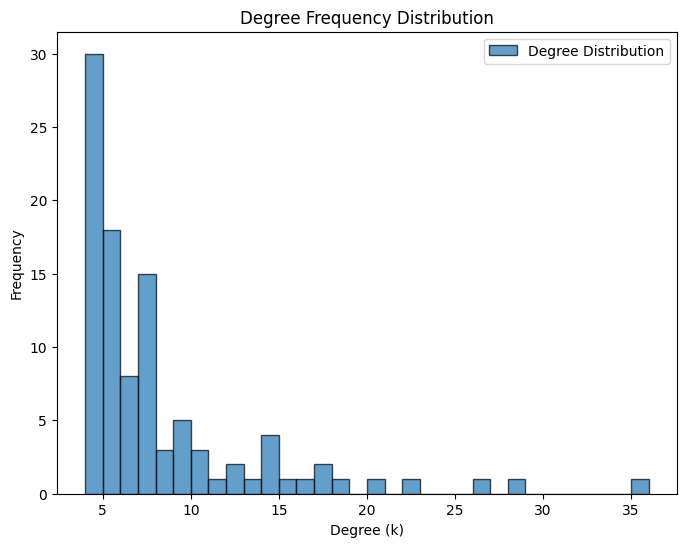

In [231]:

# Step 1: Plot the degree distribution as a histogram

plt.figure(figsize=(8, 6))
plt.hist(k_list, bins=range(min(k_list), max(k_list) + 2), edgecolor='black', alpha=0.7, label='Degree Distribution')
plt.xlabel('Degree (k)')
plt.ylabel('Frequency')
plt.title('Degree Frequency Distribution')
plt.legend()
plt.show()


## Part 2: 
*For m = 4, generate one BA network of large size, N = $10^6$ if possible or larger, and
compute its degree distribution. Make a plot showing that the prediction Eq. (3) is better
than the approximation Eq. (4, specially for small values of the degree k.*



Eq. (3) : $P_{\infty} (k) = \frac{2m(m+1)}{k(k+1)(k+2)}$

Eq.(4) : $ P_{N} (k) = P_{\infty} (k) w (\frac{k}{\sqrt(N)}) $

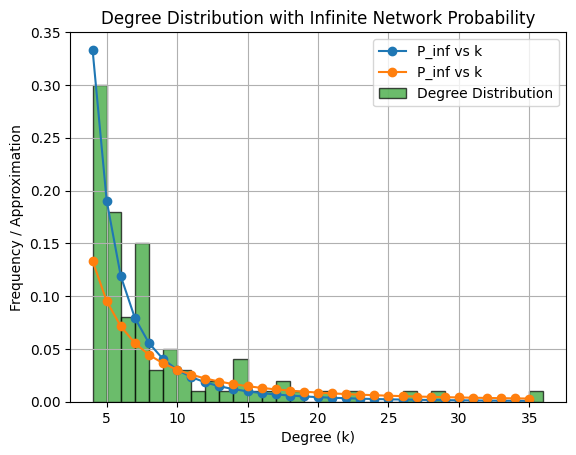

In [232]:
# Incorporate Eq. (3)

# Create list of degrees from min to max degree in k_list
degree = range(min(k_list), max(k_list) + 1)

# Compute P_inf for each degree k in degree
P_inf = []
P_N = []
for k in degree:
    # print(k)
    P_inf_i = (2 * m * (m + 1)) / (k * (k+1) * (k+2))
    P_inf.append(P_inf_i)

    # Add P_N
    P_N_i = P_inf_i * (k / np.sqrt(N))
    P_N.append(P_N_i)


# # Plot Probability Distribution P_inf
# plt.figure()
# plt.plot(degree, P_inf, marker='o', label="P_inf vs k")
# plt.xlabel("k")
# plt.ylabel("P_inf")
# plt.title("Plot of P_inf vs k")
# plt.grid(True)
# plt.legend()
# plt.show()

# # Plot Probability Distribution P_N
# plt.plot(degree, P_N, marker='o', label="P_inf vs k")
# plt.xlabel("k")
# plt.ylabel("P_N")
# plt.title("Plot of P_N vs k")
# plt.grid(True)
# plt.legend()
# plt.show()

# Plot Probability with Frequency Distribution (Normalized)
# P_inf
plt.figure()
plt.plot(degree, P_inf, marker='o', label="P_inf vs k")
plt.xlabel("k")
plt.ylabel("P_inf")
plt.grid(True)
plt.legend()

# P_N
plt.plot(degree, P_N, marker='o', label="P_inf vs k")
plt.xlabel("k")
plt.ylabel("P_inf")
plt.title("Plot of P_inf vs k")
plt.grid(True)
plt.legend()

# Frequency Distribution
plt.hist(k_list, bins=range(min(k_list), max(k_list) + 2), density=True, edgecolor='black', alpha=0.7, label='Degree Distribution')
plt.xlabel('Degree (k)')
plt.ylabel('Frequency / Approximation')
plt.title('Degree Distribution with Infinite Network Probability')
plt.legend()
plt.show()




## Part 3:

*For m = 4, compute the average degree distribution PN (k) for BA networks with size
N = 50, 100, 200 and 500. Perform averages over a number of M = 10000 different
networks. For the averages, make a histogram accumulated the degrees of all the networks
generates and apply normalization at the end. Check the finite size corrections in Eq. (4)
by plotting, for the different values of N the Pest(k)/P∞(k) as a function of k, where
Pest(k) is the average degree distribution that you have estimated numerically.*